# __Point Operators__

# __Learning Objectives:__

After completing this reading material, you will be able to:

1. Define Image Processing
2. Understand Image Manipulation
3. Understand Point Operators
4. Understand the Histogram of Image

## __Image Processing__

__Introduction__

Image processing is a method of performing certain image operations to obtain an enhanced image or extract some useful information from it. It is a form of signal processing in which input is an image, and output may be image or features/functions associated with that image.

In general, Image processing may include
: Importing the image via image acquisition tools; Analyzing and manipulating the image; Output in which results are altered based on image analysis, etc.

__In this section, we will cover analyzing and manipulating the image.__

# __Image Processing operator:__

A general image processing operator is a function that takes one or more input images and produces an output image.
The image transformation can be seen as:
* Point operators (pixel transforms)
* Neighbourhood (area-based) operators/ filters


__Point Operators__

The Point operators are a simple image manipulation method in image processing in which output pixel value depends only on the corresponding input value.

It Includes:
1. Brightness and contrast adjustment.
2. Color correction and color transformation.







__Brightness and contrast adjustment__

<image>
<center>
<!-- <img src='https://drive.google.com/uc?id=1R322EDdh5-_PVQ5-ZAidyxEnu5lB52Tc'/> -->
<img src= "https://i.postimg.cc/9Mf5qd2N/image.png"/>
<Figcaption>Figure 1: Brightness and Contrast adjustment using Point Operator</Figcaption>
</center>
</image>

Recall the chapter `Image as a Matrix.`

- Input Image: $f(x,y)$

- Output Image: $g(x,y)$

where $x$ and $y$ are horizontal and vertical co-ordinates pointing to a pixel of an image.

The value of function $f(x,y)$ gives the characteristic of the point on an image

You can represent Images as a function too.

- Input Image: $f(k)$

- Output Image: $g(k)$

Where $K = (x,y)$ you can change value of x and y because they are horizontal and vertical co-ordinates that gives pixel intensity value.

The brightness and Contrast adjustment using point operator can be represented as:



$g(k) = a~.f(k) + b$

where,

* $a$ is gain and $a>0$ and controls contrast,

* $b$ is bias and controls brightness

_You can think of f(k) as the source image pixels and g(k) as the output image pixels. Then, more conveniently we can write the expression as_


$g(x,y)= a⋅f(x,y)+b$

where `x` and `y` indicates that the pixel is located in the `x-th row and yth column.`


* To selectively darken
the sky or when modeling vignetting in an optical system you can spatially change $a ~ and ~b $


<image>
<center>
<!-- <img src='https://drive.google.com/uc?id=1UuJ_3xY8UgrYqtn6TRuGFZzz12Tg5ovX' /> -->
<img src="https://i.postimg.cc/fWpnJSrB/image.png"/>
<Figcaption>Figure 2: Working/Math of Point Operators</Figcaption>
</center>
</image>


The value of $a~ and~ b$ is [broadcasted](https://numpy.org/doc/stable/user/basics.broadcasting.html)  and the point operation is applied as shown in the figure.



* If $b > 0$ Brightness  increases else Brightness decreases.

* If $a > 1$ contrast is increased.
* If $a < 1$ contrast is reduced
* If $a$ is negative dark area becomes light and light area becomes dark.

__Example:__
$g(x,y)= a⋅f(x,y)+b$

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [3]:
!wget --no-check-certificate 'https://www.publicdomainpictures.net/pictures/20000/velka/bush-roses-117101295939187IVE.jpg' -O flower.PNG

--2025-08-12 13:06:40--  https://www.publicdomainpictures.net/pictures/20000/velka/bush-roses-117101295939187IVE.jpg
Resolving www.publicdomainpictures.net (www.publicdomainpictures.net)... 2606:4700:10::ac42:8c37, 2606:4700:10::ac42:863c, 172.66.140.55, ...
Connecting to www.publicdomainpictures.net (www.publicdomainpictures.net)|2606:4700:10::ac42:8c37|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 277649 (271K) [image/jpeg]
Saving to: ‘flower.PNG’

flower.PNG          100%[===================>] 271.14K   547KB/s    in 0.5s    

2025-08-12 13:06:42 (547 KB/s) - ‘flower.PNG’ saved [277649/277649]



__Example__

In [4]:
# Read image given
image = cv2.imread('flower.PNG',0)

We will apply some operation on this Image and store the result.



* Initial pixel values equal to zero
* Same size and type as the original image

In [5]:
new_image = np.zeros(image.shape, image.dtype)

_In this section first we will use an arbitrary value of $a ~and~ b$._

_Use $ a=2.5 ~ and ~ b=5$_

In [6]:
a = 2.5 # contrast control
b = 5 #  brightness control

In [7]:
new_image

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

Do the operation $g(x,y) = a * f(x,y) + b$

The simplest way to access the pixels  is to use 'for' loops.


In [8]:
image.shape

(960, 1280)

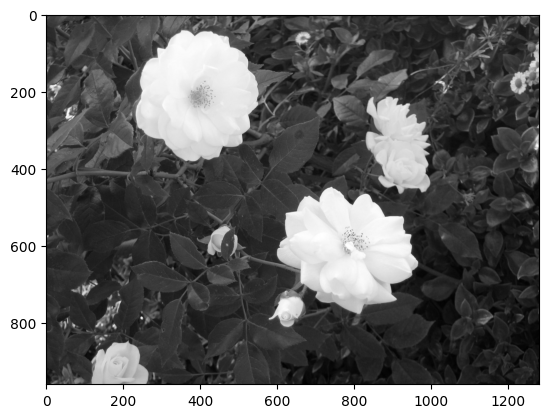

In [9]:
plt.imshow(image,cmap='gray')

In [10]:
for y in range(image.shape[0]):
    for x in range(image.shape[1]):
        new_image[y,x] = np.clip(a*image[y,x] + b, 0, 255)

In [11]:
new_image[0:5,0:5]

array([[217, 217, 205, 185, 190],
       [255, 247, 222, 190, 185],
       [255, 255, 242, 207, 185],
       [255, 255, 250, 225, 192],
       [247, 235, 232, 215, 187]], dtype=uint8)

Display New Image.

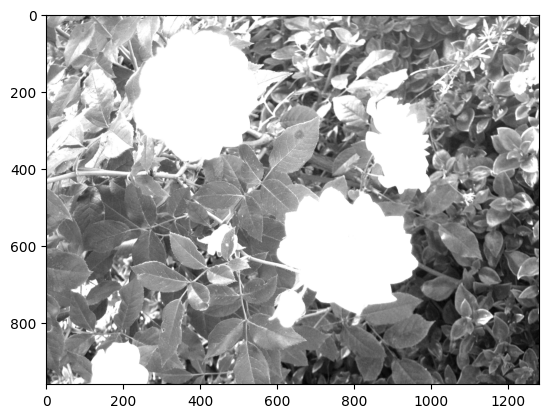

In [12]:
plt.imshow(new_image,cmap='gray')

OpenCV provides an alternative and optimzed solution to the for loops to perform the action


```
new_image = cv.convertScaleAbs(image, alpha=alpha, beta=beta)
```

Let's use the Alternative technique using different values of `a and b.`

In [13]:
#@title Plot Two Image
def plot_two_images(image, new_image,title1, title2):
    """
    Plot two Images

    Parameters
    ----------
    image:  Image or numpy.ndarray
        First Image to be plotted.
    new_image: a number or float or int
        Second Image to be plotted.
    title1: text or string
        Title for First Image
    title2: text or string
        Title for second Image
    """
    f, axes = plt.subplots(1, 2 , figsize=(10,8))
    axes[0].imshow(image,cmap='gray')
    axes[1].imshow(new_image,cmap='gray')
    plt.setp(axes[0], xlabel=title1)
    plt.setp(axes[1], xlabel=title2)
    f.tight_layout()
    plt.savefig('Image point operator.PNG')
    plt.show()

In [14]:
new_image = cv2.convertScaleAbs(image, alpha=a, beta=b)

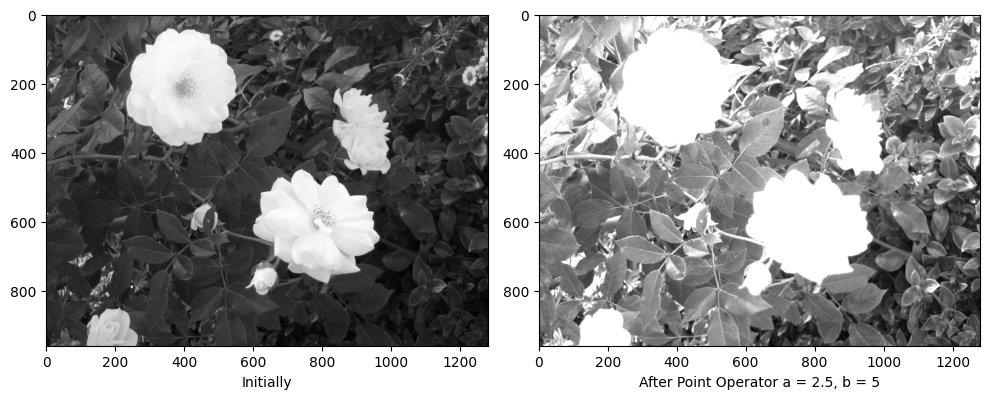

In [15]:
plot_two_images(image,new_image,title1='Initially', title2='After Point Operator a = 2.5, b = 5')

In [16]:
new_image_2 = cv2.convertScaleAbs(image, alpha=3, beta=10)

In [ ]:
splot_two_images(image, new_image_2, title1="Original Grayscale", title2="After Point Operator a = 3, b=5")

# __Point Operators in  RGB image.__


We can apply the point operators the same way we did it on a gray scale image. The only difference is on how we access the pixels.

Recall from previous chapters that there are 3 channels in an RGB image. So, we need to select individual pixels, from a 3D tensor. In terms of simple, and using for loops we can access all the pixels in the following manner:

```
iterate along the width:
    iterate along the height:
        iterate along the channels:
            point_operation in a pixel
```


In [ ]:
color_image_original = cv2.imread('flower.PNG',1)
color_image_new = np.zeros(color_image_original.shape, image.dtype)

In [ ]:
for width in range(color_image_original.shape[0]):
    for height in range(color_image_original.shape[1]):
        for channels in range(color_image_original.shape[2]):
            color_image_new[width,height,channels] = np.clip(
                a*color_image_original[width,height,channels] + b,
                0,
                255
            )

First, for loop runs width number of times, Second, runs a height number of times, and the third runs three times for each channel for RGB Image.

[np.clip()](https://numpy.org/doc/stable/reference/generated/numpy.clip.html) limits the values in a particular range. For this example np.clip() makes sure the output value doesn’t go beyond 0 to 255.

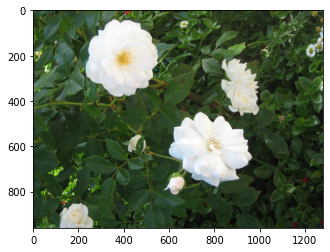

In [ ]:
plt.imshow(cv2.cvtColor(color_image_original, cv2.COLOR_BGR2RGB))

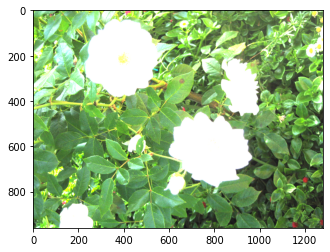

In [ ]:
plt.imshow(cv2.cvtColor(color_image_new, cv2.COLOR_BGR2RGB))

Due to brightness and contrast enhancement Image looks more bright. Leaves are more clear now.

The order of the looping can be changed. Since the point operators work on per pixel basis, we are concerned with the part where we apply the point operation in a pixel, and not how to get to the pixels.

```
iterate the height:
    iterate along the width:
        iterate along the channels:
            point_operation in a pixel
```

In [ ]:
for height in range(color_image_original.shape[1]):
    for width in range(color_image_original.shape[0]):
        for channels in range(color_image_original.shape[2]):
            color_image_new[width, height, channels] = np.clip(
                a * color_image_original[width, height, channels] + b,
                0,
                255
            )

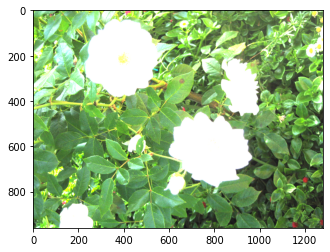

In [ ]:
plt.imshow(cv2.cvtColor(color_image_new, cv2.COLOR_BGR2RGB))

We can apply they `cv2.convertSacleAbs` function for color iamges as well.

In [ ]:
color_image_changed = cv2.convertScaleAbs(color_image_original, alpha=a, beta=b)

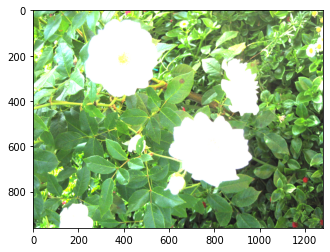

In [ ]:
plt.imshow(cv2.cvtColor(color_image_changed, cv2.COLOR_BGR2RGB))

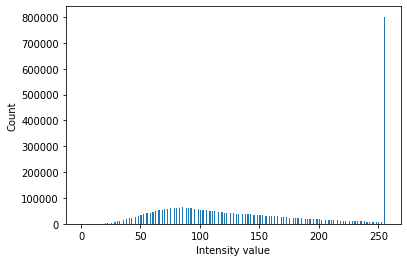

In [ ]:
plt.hist(color_image_changed.ravel(),256,[0,256])
plt.xlabel("Intensity value")
plt.ylabel("Count")
plt.show()

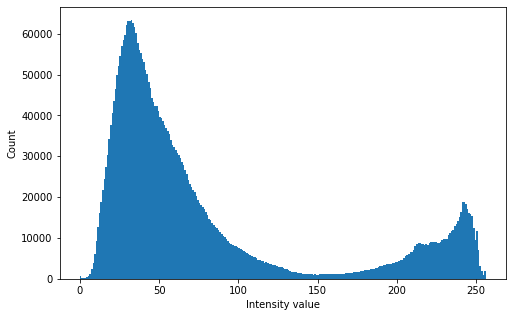

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(cv2.cvtColor(color_image_original, cv2.COLOR_BGR2RGB).ravel(),256,[0,256])
plt.xlabel("Intensity value")
plt.ylabel("Count")
plt.show()

We can see that the 3 different process yield the same result.

# __Histogram__


__Introduction__
Sometimes you want to enhance your image's contrast or expand the contrast in a particular region while sacrificing the detail in colors that don't matter much. The histogram is a useful instrument for finding exciting areas. Use the `hist()` function to construct a histogram of our image data.


__What is Histogram?__

In general histogram is a frequency distribution.

__Image Histogram__

The histogram gives the distribution of intensity of an image. It is a plot of pixel values on the X-axis and the corresponding number of pixels on the Y-axis.

 A histogram can tell you whether your image is exposed correctly, whether the brightness is harsh or flat, and what improvements will work best.

We will discuss more detail about histograms in the next chapter.

__Comparing result of point operators on the image__

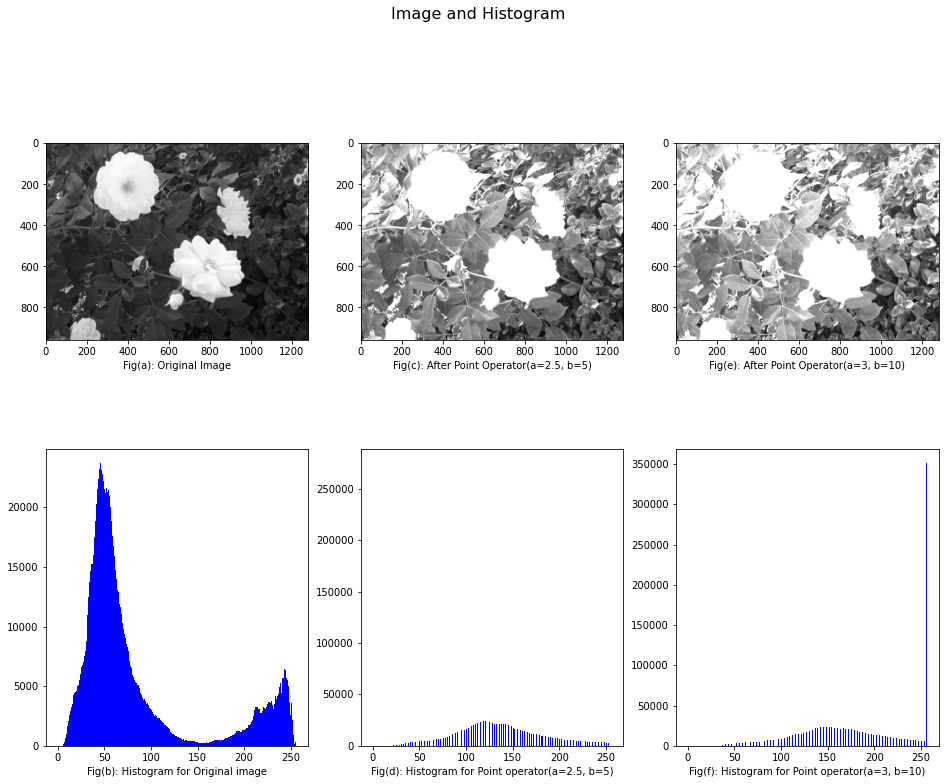

In [ ]:
#@title Plot Images
f, axes = plt.subplots(2, 3 , figsize=(16,12))
axes[0,0].imshow(image,cmap='gray')
axes[0,1].imshow(new_image,cmap='gray')
axes[0,2].imshow(new_image_2,cmap='gray')
axes[1,0].hist(image.flatten(),256,[0,256], color = 'blue')
axes[1,1].hist(new_image.flatten(),256,[0,256], color = 'b')
axes[1,2].hist(new_image_2.flatten(),256,[0,256], color = 'b')

plt.setp(axes[0,0], xlabel='Fig(a): Original Image')
plt.setp(axes[0,1], xlabel='Fig(c): After Point Operator(a=2.5, b=5)')
plt.setp(axes[0,2], xlabel='Fig(e): After Point Operator(a=3, b=10)')

plt.setp(axes[1,0], xlabel='Fig(b): Histogram for Original image')
plt.setp(axes[1,1], xlabel='Fig(d): Histogram for Point operator(a=2.5, b=5)')
plt.setp(axes[1,2], xlabel='Fig(f): Histogram for Point operator(a=3, b=10)')

# f.tight_layout()
f.suptitle("Image and Histogram", fontsize=16)
plt.savefig('Image hist point operator.PNG')
plt.show()
plt.close()



In the above image, we can see the histograms for the original image (fig(b)) and the image after simple point operation (fig(d) and fig(f)). The histogram can be a very useful graphical tool to get to know about the distribution and intensities of the pixels in our image.

_The conclusion of this histogram plot is every image has different histograms. A small manipulation in image pixels results in a change in the histogram._

__Let's See histogram of RGB channels in color Image.__

In [ ]:
image = cv2.imread('flower.PNG',1)
plt.figure(figsize=(12, 7))
channel = ['b', 'g', 'r']
label = ["Blue channel", "Green Channel", "Red Channel"]
for i, col in enumerate(channel):
    hist = cv2.calcHist([image], [i], None, [256], [0, 256])
    plt.plot(hist, color = col, label=label[i]),plt.legend(label)
    plt.xlim([0, 256])
plt.xlabel("Histogram of RGB channels in color Image")
plt.show()

# Key Take Aways

- In Image Processing, you perform some operation on the Image.
- The simplest kinds of image processing transform are point operators.

-  Point operators include brightness and contrast adjustments as well as color correction.

- Brightness and contrast adjustment using pixel transforms:

  $g(k) = a~.f(k) + b$

  where,

  $a$ is gain and $a>0$ and controls contrast,

  $b$ is a bias and controls the brightness

  By adjusting the value of `a and b,` you can selectively adjust brightness and contrast.


# References

Szeliski, R. (2010). Computer vision: algorithms and applications. Springer Science & Business Media.

Gonzalez, R. C., Woods, R. E., & Eddins, S. L. (2004). Digital image processing using MATLAB. Pearson Education India.




In [ ]:
!wget --no-check-certificate  'https://upload.wikimedia.org/wikipedia/commons/9/94/Underexposed_photo.JPG' -O underexosed.jpg

--2020-12-24 03:37:26--  https://upload.wikimedia.org/wikipedia/commons/9/94/Underexposed_photo.JPG
Resolving upload.wikimedia.org (upload.wikimedia.org)... 208.80.153.240, 2620:0:860:ed1a::2:b
Connecting to upload.wikimedia.org (upload.wikimedia.org)|208.80.153.240|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3748472 (3.6M) [image/jpeg]
Saving to: ‘underexosed.jpg’

underexosed.jpg     100%[===================>]   3.57M  15.1MB/s    in 0.2s    

2020-12-24 03:37:26 (15.1 MB/s) - ‘underexosed.jpg’ saved [3748472/3748472]



In [ ]:
im = cv2.imread('underexosed.jpg')

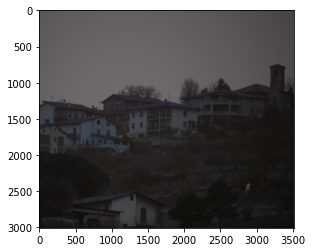

In [ ]:
plt.imshow(im)
plt.savefig('under.png')

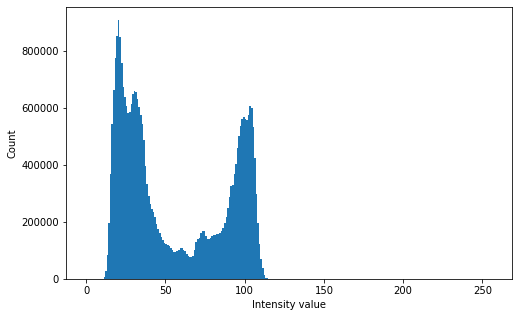

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(im.ravel(),256,[0,256])
plt.xlabel("Intensity value")
plt.ylabel("Count")
plt.savefig('underhist.png')
plt.show()

In [ ]:
new_image = cv2.convertScaleAbs(im, alpha=3, beta=5)

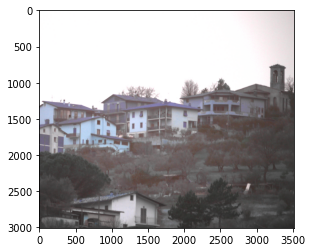

In [ ]:
plt.imshow(new_image)
plt.savefig('pointop.png')
plt.show()

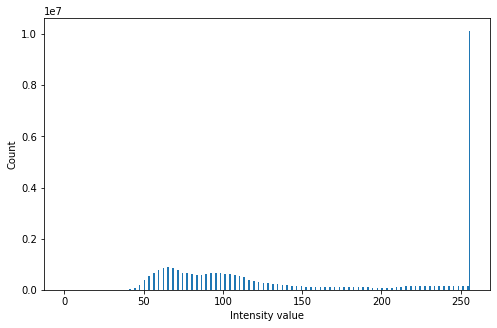

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(new_image.ravel(),256,[0,256])
plt.ylabel("Count")
plt.xlabel("Intensity value")
plt.savefig('pointophist.png')
plt.show()

In [ ]:
!wget --no-check-certificate  'https://upload.wikimedia.org/wikipedia/commons/6/67/Overexposed_photo.JPG' -O overexposed.jpg

--2020-12-24 03:44:29--  https://upload.wikimedia.org/wikipedia/commons/6/67/Overexposed_photo.JPG
Resolving upload.wikimedia.org (upload.wikimedia.org)... 208.80.153.240, 2620:0:860:ed1a::2:b
Connecting to upload.wikimedia.org (upload.wikimedia.org)|208.80.153.240|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4566847 (4.4M) [image/jpeg]
Saving to: ‘overexposed.jpg’

overexposed.jpg     100%[===================>]   4.35M  16.0MB/s    in 0.3s    

2020-12-24 03:44:30 (16.0 MB/s) - ‘overexposed.jpg’ saved [4566847/4566847]



In [ ]:
filename = 'overexposed.jpg'

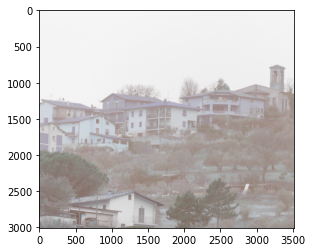

In [ ]:
im = cv2.imread(filename)
plt.imshow(im)
plt.savefig('overexposed_slide.png')

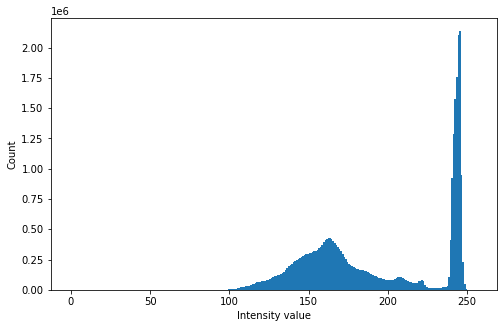

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(im.ravel(),256,[0,256])
plt.ylabel("Count")
plt.xlabel("Intensity value")
plt.savefig('overexposed hist.png')
plt.show()

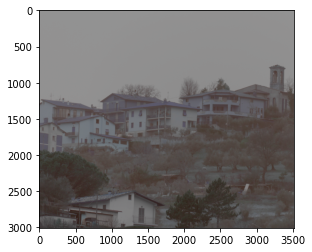

In [ ]:
new_image = cv2.convertScaleAbs(im, alpha=0.8, beta=-50)
plt.imshow(new_image)
plt.savefig('overexposed-underexposed.png')
plt.show()

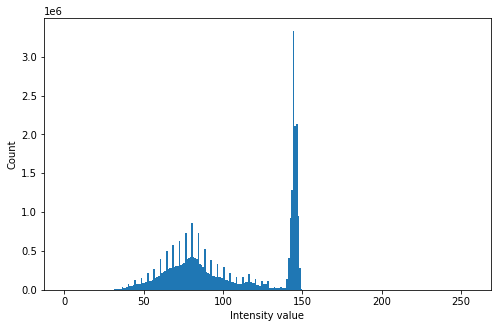

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(new_image.ravel(),256,[0,256])
plt.ylabel("Count")
plt.xlabel("Intensity value")
plt.savefig('overexposed-underexposed-hist.png')
plt.show()